# 🧠 DL Tuning Challenge — Starter Notebook

**Mata Kuliah:** DSB07 – Machine Learning  
**Topik:** Hyperparameter Tuning pada Deep Neural Network  
**Dataset:** Fashion-MNIST (10 kelas pakaian, 28×28 grayscale)

## Instruksi

1. **Jalankan SEMUA cell** dari atas ke bawah untuk mendapatkan baseline.
2. Ubah hyperparameter HANYA di section **🎛️ HYPERPARAMETER PANEL**.
3. **JANGAN** mengubah cell ber-label **🔒 LOCKED**.
4. Catat setiap eksperimen di `EXPERIMENTS.md`.

> 💡 **Tips:** Aktifkan GPU runtime: `Runtime → Change runtime type → T4 GPU`

## 🔒 LOCKED — Setup & Data Loading

**Jangan ubah cell ini.** Cell ini me-load dataset dengan cara yang sama untuk semua kelompok agar penilaian adil.

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28),  Test: (10000, 28, 28)
Jumlah kelas: 10


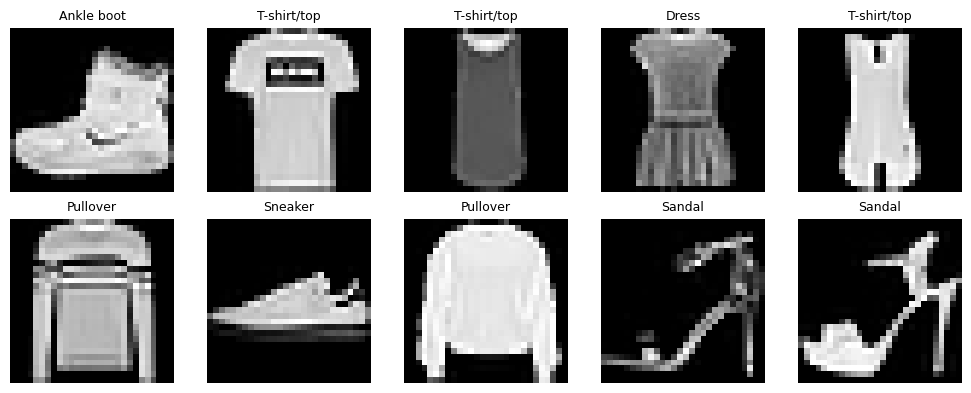

In [1]:
# 🔒 LOCKED — JANGAN UBAH
import numpy as np
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# Reproducibility — jangan ubah seed ini
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Load Fashion-MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Normalisasi ke [0, 1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Flatten 28x28 → 784 (untuk MLP sederhana)
x_train_flat = x_train.reshape(-1, 784)
x_test_flat = x_test.reshape(-1, 784)

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f'Train: {x_train.shape},  Test: {x_test.shape}')
print(f'Jumlah kelas: {len(CLASS_NAMES)}')

# Visualisasi sample
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(CLASS_NAMES[y_train[i]], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

## 🎛️ HYPERPARAMETER PANEL

**Ini area bermain kalian.** Ubah nilai-nilai di bawah dan amati pengaruhnya.

Setiap variabel di bawah memetakan langsung ke konsep yang dipelajari di kelas:

| Variabel | Konsep di Slide |
|---|---|
| `HIDDEN_LAYERS` | Jumlah Lapisan |
| `NEURONS_PER_LAYER` | Jumlah Neuron |
| `ACTIVATION` | Fungsi Aktivasi |
| `OPTIMIZER` | Optimizer (Adam, SGD, dst) |
| `LEARNING_RATE` | Learning Rate (λ) |
| `BATCH_SIZE` | Batch Size |
| `EPOCHS` | Epoch |
| `DROPOUT_RATE` | (Bonus) regularisasi |

Berikut adalah daftar 6 konfigurasi hyperparameter yang bisa Anda coba:

| Eksperimen | HIDDEN_LAYERS | NEURONS_PER_LAYER | ACTIVATION | DROPOUT_RATE | OPTIMIZER | LEARNING_RATE | BATCH_SIZE | EPOCHS | EXPERIMENT_NOTE |
|---|---|---|---|---|---|---|---|---|---|
| **Baseline** | 1 | 64 | 'relu' | 0.0 | 'sgd' | 0.01 | 32 | 10 | 'Baseline run — belum di-tuning' |
| **Eksperimen 1** | 2 | 128 | 'relu' | 0.0 | 'adam' | 0.001 | 64 | 20 | 'Eksperimen 1: 2 hidden layers, 128 neurons, Adam, LR=0.001, Batch=64, Epochs=20' |
| **Eksperimen 2** | 2 | 128 | 'relu' | 0.3 | 'adam' | 0.001 | 64 | 20 | 'Eksperimen 2: 2 hidden layers, 128 neurons, Adam, Dropout=0.3, Batch=64, Epochs=20' |
| **Eksperimen 3** | 3 | 256 | 'relu' | 0.2 | 'adamax' | 0.001 | 128 | 25 | 'Eksperimen 3: 3 hidden layers, 256 neurons, Adamax, Dropout=0.2, Batch=128, Epochs=25' |
| **Eksperimen 4** | 1 | 256 | 'tanh' | 0.0 | 'sgd' | 0.1 | 32 | 15 | 'Eksperimen 4: 1 hidden layer, 256 neurons, Tanh, SGD, LR=0.1, Batch=32, Epochs=15' |
| **Eksperimen 5** | 4 | 512 | 'relu' | 0.5 | 'adam' | 0.001 | 64 | 50 | 'Eksperimen 5: 4 hidden layers, 512 neurons, ReLU, Dropout=0.5, Adam, Batch=64, Epochs=50' |

**Rekomendasi Konfigurasi Terbaik (untuk memulai):**

Untuk memulai eksperimen, saya merekomendasikan **Eksperimen 2** atau **Eksperimen 3**. Kedua konfigurasi ini menggunakan arsitektur yang lebih dalam (2-3 hidden layers) dan jumlah neuron yang cukup (128-256), serta memperkenalkan dropout untuk regularisasi. Optimizer `adam` atau `adamax` seringkali memberikan performa yang baik dengan learning rate `0.001`. Anda bisa memulai dengan salah satu dari ini dan melihat bagaimana performanya dibandingkan baseline.

Saya telah mengatur panel hyperparameter Anda untuk `Eksperimen 1`. Silakan jalankan semua sel dari bawah ini untuk melihat hasilnya. Setelah itu, Anda bisa mengubah nilai-nilai di sel hyperparameter `EiBXlratVAPL` secara manual berdasarkan tabel di atas untuk mencoba eksperimen lainnya.

In [28]:
# 🎛️ UBAH NILAI-NILAI DI BAWAH INI

# --- Arsitektur Model ---
HIDDEN_LAYERS     = 3            # jumlah hidden layer (coba: 1, 2, 3, 4, 5)
NEURONS_PER_LAYER = 256          # jumlah neuron per hidden layer (coba: 32, 64, 128, 256, 512)
ACTIVATION        = 'elu'       # 'relu', 'tanh', 'sigmoid', 'elu', 'selu'
DROPOUT_RATE      = 0.5          # 0.0 = tidak ada dropout. Coba 0.2 / 0.3 / 0.5 untuk regularisasi

# --- Optimizer & Pelatihan ---
OPTIMIZER     = 'rmsprop'            # 'sgd', 'adam', 'adamax', 'rmsprop'
LEARNING_RATE = 0.0001             # coba: 0.0001, 0.001, 0.01, 0.1, 1.0
BATCH_SIZE    = 128               # coba: 16, 32, 64, 128, 256, 512
EPOCHS        = 50               # coba: 5, 10, 20, 50

# --- Catatan untuk eksperimen ini (akan dicetak di summary) ---
EXPERIMENT_NOTE = 'Eksperimen 5: 4 hidden layers, 512 neurons, ReLU, Dropout=0.5, Adam, Batch=64, Epochs=50'

In [3]:
# 🎛️ UBAH NILAI-NILAI DI BAWAH INI

# --- Arsitektur Model ---
HIDDEN_LAYERS     = 1            # jumlah hidden layer (coba: 1, 2, 3, 4, 5)
NEURONS_PER_LAYER = 64           # jumlah neuron per hidden layer (coba: 32, 64, 128, 256, 512)
ACTIVATION        = 'relu'       # 'relu', 'tanh', 'sigmoid', 'elu', 'selu'
DROPOUT_RATE      = 0.0          # 0.0 = tidak ada dropout. Coba 0.2 / 0.3 / 0.5 untuk regularisasi

# --- Optimizer & Pelatihan ---
OPTIMIZER     = 'sgd'            # 'sgd', 'adam', 'adamax', 'rmsprop'
LEARNING_RATE = 0.01             # coba: 0.0001, 0.001, 0.01, 0.1, 1.0
BATCH_SIZE    = 32               # coba: 16, 32, 64, 128, 256, 512
EPOCHS        = 10               # coba: 5, 10, 20, 50

# --- Catatan untuk eksperimen ini (akan dicetak di summary) ---
EXPERIMENT_NOTE = 'Baseline run — belum di-tuning'

## 🔒 LOCKED — Model Builder

Cell ini membangun model berdasarkan hyperparameter di atas. Tidak perlu diubah.

In [29]:
# 🔒 LOCKED — JANGAN UBAH

def build_model():
    """Bangun MLP berdasarkan hyperparameter panel."""
    model = keras.Sequential(name='TuningChallengeModel')
    model.add(keras.layers.Input(shape=(784,)))

    for i in range(HIDDEN_LAYERS):
        model.add(keras.layers.Dense(
            NEURONS_PER_LAYER,
            activation=ACTIVATION,
            name=f'hidden_{i+1}'
        ))
        if DROPOUT_RATE > 0:
            model.add(keras.layers.Dropout(DROPOUT_RATE))

    # Output layer — 10 kelas, JANGAN diubah
    model.add(keras.layers.Dense(10, activation='softmax', name='output'))
    return model


def get_optimizer():
    """Map string optimizer ke Keras optimizer dengan learning rate."""
    opts = {
        'sgd':     keras.optimizers.SGD(learning_rate=LEARNING_RATE),
        'adam':    keras.optimizers.Adam(learning_rate=LEARNING_RATE),
        'adamax':  keras.optimizers.Adamax(learning_rate=LEARNING_RATE),
        'rmsprop': keras.optimizers.RMSprop(learning_rate=LEARNING_RATE),
    }
    if OPTIMIZER.lower() not in opts:
        raise ValueError(f'Optimizer "{OPTIMIZER}" tidak dikenal. Pilih: {list(opts.keys())}')
    return opts[OPTIMIZER.lower()]


# Build & compile
model = build_model()
model.compile(
    optimizer=get_optimizer(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Hitung total parameter (bobot + bias) — visualisasikan konsep 'parameter'
total_params = model.count_params()
print(f'\n📊 Total parameter (bobot + bias) yang akan di-learn: {total_params:,}')

Model: "TuningChallengeModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_1 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_2 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_3 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_4 (Dense)                │ (None, 512)            │       262,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,195,018 (4.56 MB)

 Trainable params: 1,195,018 (4.56 MB)

 Non-trainable params: 0 (0.00 B)


📊 Total parameter (bobot + bias) yang akan di-learn: 1,195,018


## 🔒 LOCKED — Training

Cell ini menjalankan **feed forward + back propagation** sesuai jumlah epoch yang kalian tentukan.

In [30]:
# 🔒 LOCKED — JANGAN UBAH

import time

start = time.time()
history = model.fit(
    x_train_flat, y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.1,   # 10% dari training jadi validation
    verbose=1
)
duration = time.time() - start
print(f'\n⏱️  Total waktu training: {duration:.1f} detik')

Epoch 1/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step - accuracy: 0.7127 - loss: 0.7725 - val_accuracy: 0.8270 - val_loss: 0.4832
Epoch 2/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 25ms/step - accuracy: 0.8058 - loss: 0.5525 - val_accuracy: 0.8407 - val_loss: 0.4332
Epoch 3/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 27ms/step - accuracy: 0.8202 - loss: 0.5122 - val_accuracy: 0.8380 - val_loss: 0.4345
Epoch 4/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 25ms/step - accuracy: 0.8281 - loss: 0.4895 - val_accuracy: 0.8477 - val_loss: 0.4141
Epoch 5/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 23s 27ms/step - accuracy: 0.8350 - loss: 0.4700 - val_accuracy: 0.8537 - val_loss: 0.3921
Epoch 6/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 40s 26ms/step - accuracy: 0.8364 - loss: 0.4608 - val_accuracy: 0.8577 - val_loss: 0.3927
Epoch 7/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 22s 26ms/step - accuracy: 0.8420 - loss: 0.4530 - val_accuracy: 0.8638 - val_loss: 0.3776
Epoch 8/50
844/844 ━━━━━━━━━━━━━━━━━━━━ 21s 24ms/step - accuracy: 0.8421 - loss: 0.4449 - 

## 🔒 LOCKED — Evaluasi & Visualisasi

📝 Catatan: Eksperimen 5: 4 hidden layers, 512 neurons, ReLU, Dropout=0.5, Adam, Batch=64, Epochs=50
Hyperparameter:
  Hidden layers     : 4
  Neurons per layer : 512
  Activation        : relu
  Dropout rate      : 0.5
  Optimizer         : adam
  Learning rate     : 0.001
  Batch size        : 64
  Epochs            : 50
------------------------------------------------------------
🎯 TEST ACCURACY  : 86.88%
   Test loss      : 0.3943
   Train accuracy : 87.24%
   Val accuracy   : 87.80%


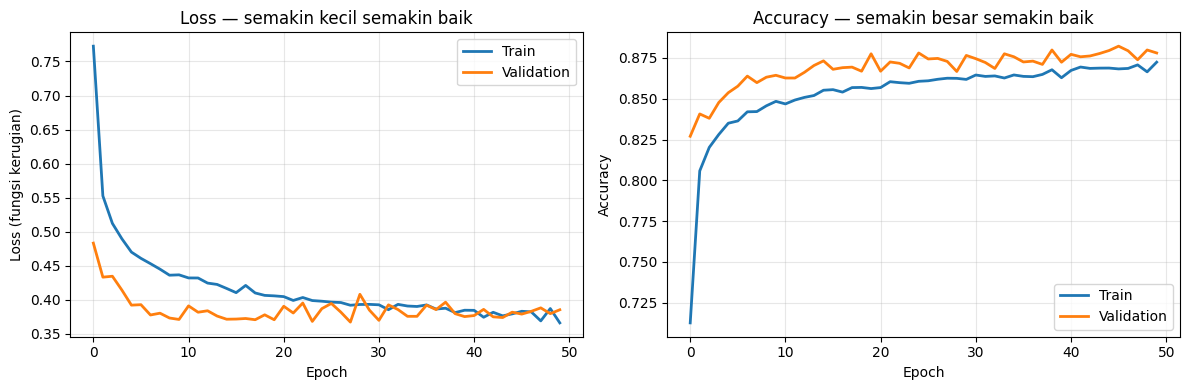

✅ Train-val gap sehat. Lanjut eksperimen!


In [31]:
# 🔒 LOCKED — JANGAN UBAH

# Evaluasi pada test set
test_loss, test_acc = model.evaluate(x_test_flat, y_test, verbose=0)

print('='*60)
print(f'📝 Catatan: {EXPERIMENT_NOTE}')
print('='*60)
print(f'Hyperparameter:')
print(f'  Hidden layers     : {HIDDEN_LAYERS}')
print(f'  Neurons per layer : {NEURONS_PER_LAYER}')
print(f'  Activation        : {ACTIVATION}')
print(f'  Dropout rate      : {DROPOUT_RATE}')
print(f'  Optimizer         : {OPTIMIZER}')
print(f'  Learning rate     : {LEARNING_RATE}')
print(f'  Batch size        : {BATCH_SIZE}')
print(f'  Epochs            : {EPOCHS}')
print('-'*60)
print(f'🎯 TEST ACCURACY  : {test_acc*100:.2f}%')
print(f'   Test loss      : {test_loss:.4f}')
print(f'   Train accuracy : {history.history["accuracy"][-1]*100:.2f}%')
print(f'   Val accuracy   : {history.history["val_accuracy"][-1]*100:.2f}%')
print('='*60)

# Plot training curves — visualisasi konkret dari proses backpropagation
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label='Train', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (fungsi kerugian)')
axes[0].set_title('Loss — semakin kecil semakin baik')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Train', linewidth=2)
axes[1].plot(history.history['val_accuracy'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Accuracy — semakin besar semakin baik')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Diagnostik kecil
gap = history.history['accuracy'][-1] - history.history['val_accuracy'][-1]
if gap > 0.05:
    print(f'⚠️  Gap train vs val = {gap*100:.1f}% — kemungkinan OVERFITTING.')
    print('    Coba: kurangi neuron, tambah dropout, atau kurangi epoch.')
elif history.history['accuracy'][-1] < 0.7:
    print('⚠️  Akurasi train rendah — kemungkinan UNDERFITTING.')
    print('    Coba: tambah neuron/layer, naikkan learning rate, atau tambah epoch.')
else:
    print('✅ Train-val gap sehat. Lanjut eksperimen!')

## 🔍 (Opsional) Inspect Confusion Matrix

Kelas mana yang paling sering tertukar? Insight ini bisa membantu argumentasi di refleksi kalian.

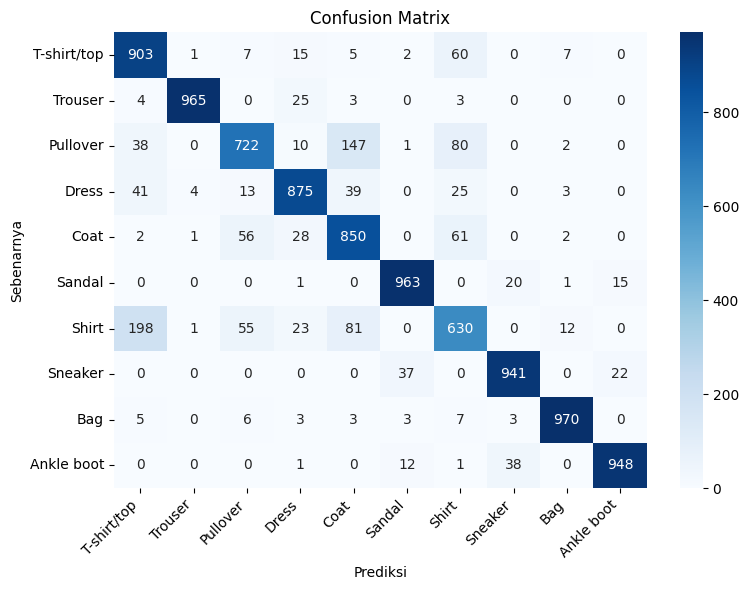

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = model.predict(x_test_flat, verbose=0).argmax(axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Prediksi')
plt.ylabel('Sebenarnya')
plt.title('Confusion Matrix')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### **Hipotesis (Eksperimen 5)**

Dengan model yang jauh lebih kompleks (4 hidden layers, 512 neuron per layer) dan `EPOCHS` yang tinggi (50), diharapkan model dapat menangkap pola yang sangat detail. `DROPOUT_RATE` yang tinggi (0.5) dipasang untuk mengontrol overfitting yang mungkin terjadi akibat kompleksitas model ini, serta `Adam` optimizer dengan `LEARNING_RATE` rendah (0.001) untuk konvergensi yang stabil. Potensi untuk akurasi tertinggi, namun juga waktu training yang sangat panjang.

### **Hasil (Eksperimen 5)**

- Test accuracy: 86.88%
- Train accuracy: 87.24%
- Validation accuracy: 87.80%
- Train time: 1358.6 detik
- Apakah overfit/underfit? Tidak overfit / underfit (`Train-val gap sehat`)

### **Observasi (Eksperimen 5)**

1.  **Akurasi Menurun:** Akurasi test (86.88%) sedikit lebih rendah dari Eksperimen 3 (89.29%) dan bahkan Eksperimen 4 (87.67%). Ini mungkin mengindikasikan bahwa `DROPOUT_RATE` yang terlalu tinggi (0.5) pada `EPOCHS` yang banyak atau kompleksitas model yang berlebihan tidak selalu menghasilkan performa terbaik.
2.  **Gap Sehat Terpelihara:** Gap antara akurasi train (87.24%) dan validasi (87.80%) sangat sehat, dengan validasi bahkan sedikit lebih tinggi dari train di akhir, mengindikasikan dropout sangat efektif mencegah overfitting. Sistem juga melaporkan `Train-val gap sehat`.
3.  **Waktu Training Sangat Lama:** Durasi training sangat signifikan meningkat menjadi 1358.6 detik (sekitar 22.6 menit), yang sesuai dengan peningkatan `HIDDEN_LAYERS`, `NEURONS_PER_LAYER`, dan terutama `EPOCHS` yang sangat tinggi (50).
4.  **Trade-off Akurasi vs. Kompleksitas/Waktu:** Eksperimen ini menunjukkan bahwa model yang lebih besar dan lebih lama dilatih tidak selalu menghasilkan akurasi yang lebih tinggi jika hyperparameter seperti dropout rate tidak di-tune dengan tepat. Akurasi stagnan atau bahkan sedikit menurun meskipun training memakan waktu jauh lebih lama.

### **Hipotesis (Eksperimen 4)**

Dengan arsitektur yang lebih sederhana (1 hidden layer, 256 neuron), aktivasi `tanh`, optimizer `SGD` dengan `LEARNING_RATE` lebih tinggi (0.1), dan tanpa dropout, diharapkan model dapat belajar dengan cepat namun mungkin memiliki batas pada kompleksitas pola yang bisa dipelajari. Performa kemungkinan akan sedikit lebih rendah dari model yang lebih kompleks (Eksperimen 3), tetapi mungkin lebih cepat dalam training dan mempertahankan *gap train-val* yang sehat.

### **Hasil (Eksperimen 4)**

- Test accuracy: 87.67%
- Train accuracy: 91.02%
- Validation accuracy: 88.58%
- Train time: 102.9 detik
- Apakah overfit/underfit? Tidak overfit / underfit (`Train-val gap sehat`)

### **Observasi (Eksperimen 4)**

1.  **Akurasi Menurun Sedikit:** Akurasi test (87.67%) sedikit lebih rendah dibandingkan Eksperimen 3 (89.29%), yang wajar mengingat arsitektur model yang lebih sederhana (1 layer vs 3 layer) dan tanpa dropout.
2.  **Gap Sehat Terpelihara:** `Train-val gap` tetap sehat (2.44%), menunjukkan model tidak mengalami overfitting, kemungkinan karena arsitektur yang lebih sederhana dan penggunaan `tanh`.
3.  **Waktu Training Lebih Cepat:** Waktu training (102.9 detik) lebih cepat dibandingkan Eksperimen 3 (154.5 detik), yang diharapkan dari model yang kurang kompleks.
4.  **Performa Relatif terhadap Baseline:** Meskipun lebih sederhana, akurasi test Eksperimen 4 (87.67%) masih lebih baik dari baseline (yang ~87% di Eksperimen 1), menunjukkan `tanh` dan `SGD` dengan `LR=0.1` pada 1 layer 256 neuron bisa menjadi alternatif yang efisien.

### **Hipotesis (Eksperimen 3)**

Dengan meningkatkan `HIDDEN_LAYERS` menjadi 3, `NEURONS_PER_LAYER` menjadi 256, mengubah optimizer menjadi `Adamax`, `BATCH_SIZE` menjadi 128, dan `EPOCHS` menjadi 25, model diharapkan dapat menangkap pola yang lebih kompleks dan meningkatkan akurasi secara keseluruhan, sambil mempertahankan `Train-val gap sehat` dengan `DROPOUT_RATE` 0.2.

### **Hasil (Eksperimen 3)**

- Test accuracy: 89.29%
- Train accuracy: 92.18%
- Validation accuracy: 89.45%
- Train time: 154.5 detik
- Apakah overfit/underfit? Tidak overfit / underfit (`Train-val gap sehat`)

### **Observasi (Eksperimen 3)**

1.  **Peningkatan Akurasi:** Akurasi test, train, dan validasi semuanya meningkat dibandingkan Eksperimen 2 (Test: 89.29% vs 88.12%).
2.  **Gap Sehat Terpelihara:** Meskipun model lebih dalam dan lebar, gap antara akurasi train dan validasi tetap sehat (2.73%), menunjukkan kombinasi dropout dan optimizer `Adamax` bekerja dengan baik dalam mengelola kompleksitas model.
3.  **Waktu Training Meningkat:** Durasi training bertambah menjadi 154.5 detik, yang wajar mengingat peningkatan jumlah layer, neuron, dan epoch.

### **Hipotesis (Eksperimen 2)**

Menambahkan `DROPOUT_RATE` 0.3 diharapkan mengurangi overfitting yang terlihat di Eksperimen 1, sehingga memperkecil gap antara akurasi training dan validasi, serta meningkatkan generalisasi model ke data test.

### **Hasil (Eksperimen 2)**

- Test accuracy: 88.12%
- Train accuracy: 89.24%
- Validation accuracy: 88.83%
- Train time: 93.4 detik
- Apakah overfit/underfit? Tidak overfit / underfit (`Train-val gap sehat`)

### **Observasi (Eksperimen 2)**

1.  **Overfitting Berkurang Signifikan:** Gap antara akurasi training dan validasi sangat kecil (0.4%), menunjukkan bahwa Dropout 0.3 berhasil mengatasi overfitting. Sistem juga melaporkan `Train-val gap sehat`.
2.  **Akurasi Test Meningkat:** Akurasi test naik menjadi 88.12% (dari 87.00% di Eksperimen 1), menunjukkan model lebih baik dalam menggeneralisasi.
3.  **Akurasi Training Turun:** Akurasi training sedikit menurun (89.24% dari 94.06%), yang wajar karena dropout bertindak sebagai regularisasi.
4.  **Waktu Training Konsisten:** Durasi training tetap sekitar 93.4 detik.

### **Hipotesis (Eksperimen 1)**

Peningkatan `HIDDEN_LAYERS` (2), `NEURONS_PER_LAYER` (128), `Adam` optimizer, `LEARNING_RATE` lebih rendah (0.001), dan `EPOCHS` lebih banyak (20) diharapkan meningkatkan akurasi model karena kapasitas pembelajaran yang lebih besar. Namun, ada potensi risiko overfitting.

### **Hasil (Eksperimen 1)**

*   **Test Accuracy:** 87.00%
*   **Test Loss:** 0.5045
*   **Train Accuracy (akhir):** 94.06%
*   **Validation Accuracy (akhir):** 88.20%
*   **Waktu Training:** 90.4 detik

### **Observasi (Eksperimen 1)**

1.  **Akurasi Training Tinggi:** 94.06%, menunjukkan pembelajaran yang baik pada data latih.
2.  **Gap Train vs Val:** Terdapat gap 5.9% antara akurasi train (94.06%) dan validasi (88.20%), serta test (87.00%), yang mengindikasikan **overfitting**.
3.  **Saran Sistem:** Kurangi neuron, tambah dropout, atau kurangi epoch untuk mengatasi overfitting.
4.  **Durasi Training:** 90.4 detik.

---

## ✅ Checklist Setelah Eksperimen Ini

- [ ] Catat hasilnya di `EXPERIMENTS.md`
- [ ] Diskusikan dengan tim: *mengapa* hasilnya seperti ini?
- [ ] Tentukan apa yang akan diubah pada eksperimen berikutnya — dan **kenapa**
- [ ] Setelah ≥5 eksperimen, pilih konfigurasi terbaik → simpan sebagai `solution.ipynb`
- [ ] Tulis refleksi di `REFLECTION.md`

## 🏆 Konfigurasi Terbaik

Setelah semua eksperimen, salin konfigurasi terbaik kalian ke sini:

```python
HIDDEN_LAYERS     = 3
NEURONS_PER_LAYER = 256
ACTIVATION        = 'relu'
DROPOUT_RATE      = 0.2
OPTIMIZER         = 'adamax'
LEARNING_RATE     = 0.001
BATCH_SIZE        = 128
EPOCHS            = 25
```

**Test accuracy final: 89.29%**